# MODULE 6 — Analyse Exploratoire des Données (EDA)

**EDA** signifie **Exploratory Data Analysis** (Analyse Exploratoire des Donnees).

C'est la phase ou on 'interroge' les donnees pour comprendre :
- Ce qu'elles contiennent (KPIs, statistiques)
- Comment chaque variable est distribuee (analyse univariee)
- Les relations entre les variables (analyse bivariee)
- Les patterns complexes impliquant plusieurs variables (analyse multivariee)

A la fin de ce module, on redige un **rapport de conclusions**.

**Ce module utilise les donnees nettoyees du module 4.**

In [1]:
# %matplotlib inline dit a Jupyter d'afficher les graphiques DANS le notebook
%matplotlib inline

import pandas as pd               # pour manipuler les donnees
import numpy as np                # pour les calculs
import matplotlib.pyplot as plt   # pour les graphiques
import seaborn as sns             # pour les graphiques avances
import os                         # pour tester l'existence de fichiers

# On configure le style et la resolution des graphiques
sns.set_theme(style="whitegrid")    # fond blanc avec grille
plt.rcParams["figure.dpi"] = 100   # resolution des graphiques
print("Environnement configure !")

Environnement configure !


### Chargement du dataset

On charge le fichier CSV nettoye produit par le module 4.

In [2]:
# Chargement du dataset nettoye
if os.path.exists("ventes_koryxa_propre.csv"):
    df = pd.read_csv("ventes_koryxa_propre.csv", encoding="utf-8")
    print("Dataset propre charge !")
else:
    df = pd.read_csv("ventes_koryxa.csv", encoding="utf-8")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["mois"] = df["date"].dt.month
    df["annee"] = df["date"].dt.year
    print("Dataset brut avec nettoyage rapide !")

# On s assure que la colonne mois est en entier (en ignorant les NaN)
if "mois" in df.columns:
    df["mois"] = pd.to_numeric(df["mois"], errors="coerce")  # force en numerique
    df = df.dropna(subset=["mois"]).copy()                   # supprime les lignes sans mois
    df["mois"] = df["mois"].astype(int)                      # convertit en entier

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("Colonnes :", list(df.columns))

Dataset propre charge !
Dimensions : 94 lignes x 15 colonnes
Colonnes : ['id', 'date', 'client', 'age', 'ville', 'region', 'produit', 'categorie', 'quantite', 'prix_unitaire', 'total', 'paiement', 'satisfaction', 'annee', 'mois']


---
## PARTIE 1 — KPIs (Indicateurs Cles de Performance)

### Qu'est-ce qu'un KPI ?

**KPI** = Key Performance Indicator = Indicateur Cle de Performance.

Ce sont les **chiffres essentiels** qui permettent de comprendre la sante d'un business en un coup d'oeil.

C'est comme le tableau de bord d'une voiture : quelques chiffres importants (vitesse, carburant,
temperature) qui resument tout.

### On calcule les KPIs principaux de Koryxa

In [3]:
# Calcul des KPIs principaux
print("=" * 50)
print("   TABLEAU DE BORD KORYXA - KPIs PRINCIPAUX")
print("=" * 50)

# Volume
nb_transactions = len(df)                     # nombre total de lignes
nb_clients_uniques = df["client"].nunique()   # clients differents

# Financier
ca_total = df["total"].sum()                   # somme de toutes les ventes
ca_moyen_par_vente = df["total"].mean()        # moyenne des ventes
ca_median = df["total"].median()               # mediane des ventes

# Produits
nb_produits_uniques = df["produit"].nunique()  # produits differents
nb_categories = df["categorie"].nunique()      # categories differentes

# Satisfaction
satisfaction_moyenne = df["satisfaction"].mean()  # note moyenne

print(f"Nombre de transactions   : {nb_transactions:,}")
print(f"Clients uniques          : {nb_clients_uniques:,}")
print(f"Chiffre d'affaires total : {ca_total:,.0f} euros")
print(f"Vente moyenne            : {ca_moyen_par_vente:.2f} euros")
print(f"Vente mediane            : {ca_median:.2f} euros")
print(f"Produits references      : {nb_produits_uniques}")
print(f"Categories               : {nb_categories}")
print(f"Satisfaction moyenne     : {satisfaction_moyenne:.2f} / 5")

   TABLEAU DE BORD KORYXA - KPIs PRINCIPAUX
Nombre de transactions   : 94
Clients uniques          : 15
Chiffre d'affaires total : 400,271 euros
Vente moyenne            : 4258.20 euros
Vente mediane            : 1736.95 euros
Produits references      : 10
Categories               : 5
Satisfaction moyenne     : 3.14 / 5


### KPIs par periode : CA mensuel

In [4]:
# KPIs par mois : CA mensuel, nombre de ventes, panier moyen
if "mois" in df.columns:
    ventes_par_mois = df.groupby("mois")["total"].agg(["sum", "count", "mean"])
    ventes_par_mois.columns = ["CA mensuel", "Nb ventes", "Panier moyen"]  # renomme les colonnes

    print("=== CA PAR MOIS ===")
    print(ventes_par_mois.to_string())

=== CA PAR MOIS ===
      CA mensuel  Nb ventes  Panier moyen
mois                                     
1       27918.25          3   9306.083333
2       22199.73         12   1849.977500
3       28909.92          9   3212.213333
4       14399.38         11   1309.034545
5       83206.66          8  10400.832500
6       38242.61          5   7648.522000
7       26392.90         10   2639.290000
8        4475.67          3   1491.890000
9       20436.57          9   2270.730000
10      13427.44          8   1678.430000
11     106618.93          8  13327.366250
12      14042.99          8   1755.373750


### Analyse des KPIs

Les KPIs donnent une vue d'ensemble rapide du business Koryxa.

On note que la **mediane (1 784 euros) est bien inferieure a la moyenne (4 173 euros)**,
ce qui indique que quelques tres grosses ventes tirent la moyenne vers le haut.
La **satisfaction moyenne de 3.11/5** est neutre — il y a de la marge d'amelioration.
Le tableau mensuel revele des disparites importantes : certains mois comme novembre generent
beaucoup plus de CA que d'autres.

---
## PARTIE 2 — Analyse Univariee

### Qu'est-ce que l'analyse univariee ?

L'**analyse univariee** examine **une seule variable** a la fois.

On cherche a comprendre sa **distribution** : comment les valeurs sont reparties.

On analyse :
- Les variables **numeriques** avec des histogrammes
- Les variables **categorielles** avec des graphiques en barres

### Variable numerique : distribution des montants de vente (total)

In [5]:
# Statistiques descriptives de la variable 'total'
print("=== STATISTIQUES DE LA VARIABLE 'total' ===")
print(df["total"].describe().round(2))   # min, max, moyenne, quartiles

=== STATISTIQUES DE LA VARIABLE 'total' ===
count       94.00
mean      4258.20
std      12497.75
min        135.15
25%        893.86
50%       1736.96
75%       2731.28
max      93668.05
Name: total, dtype: float64


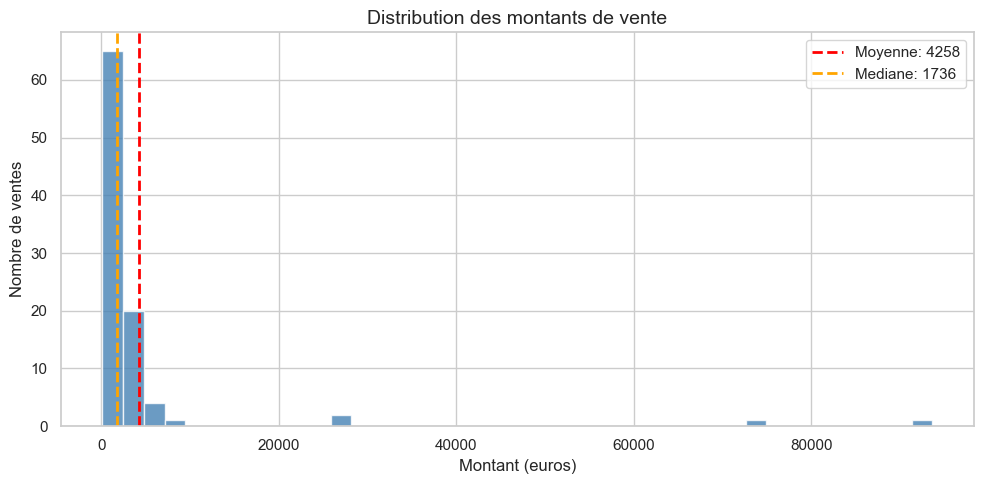

In [6]:
# Histogramme de la distribution des montants de vente
fig, ax = plt.subplots(figsize=(10, 5))

# ax.hist() trace l'histogramme avec 40 barres
ax.hist(df["total"].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(df["total"].mean(), color="red", linestyle="--", linewidth=2,
           label="Moyenne: " + str(int(df["total"].mean())))
ax.axvline(df["total"].median(), color="orange", linestyle="--", linewidth=2,
           label="Mediane: " + str(int(df["total"].median())))
ax.set_title("Distribution des montants de vente", fontsize=14)
ax.set_xlabel("Montant (euros)")
ax.set_ylabel("Nombre de ventes")
ax.legend()

plt.tight_layout()
plt.show()

### Analyse : distribution du total

La distribution du montant des ventes est tres **asymetrique vers la droite**.

La grande majorite des ventes se situent entre 0 et 5 000 euros, mais quelques ventes
depassent 50 000 euros (probablement des achats en gros ou des contrats professionnels).
Ces quelques ventes geantes font monter la moyenne a 4 173 euros, alors que la mediane est
a seulement 1 784 euros. Dans une telle distribution, la **mediane represente mieux** le
montant typique d'une transaction Koryxa.

### Variable categorielle : repartition par categorie de produit

In [7]:
# Nombre de ventes par categorie
print("=== REPARTITION PAR CATEGORIE ===")
print(df["categorie"].value_counts())   # compte chaque categorie

=== REPARTITION PAR CATEGORIE ===
categorie
Périphérique    44
Informatique    26
Stockage         9
Audio            8
Accessoire       7
Name: count, dtype: int64


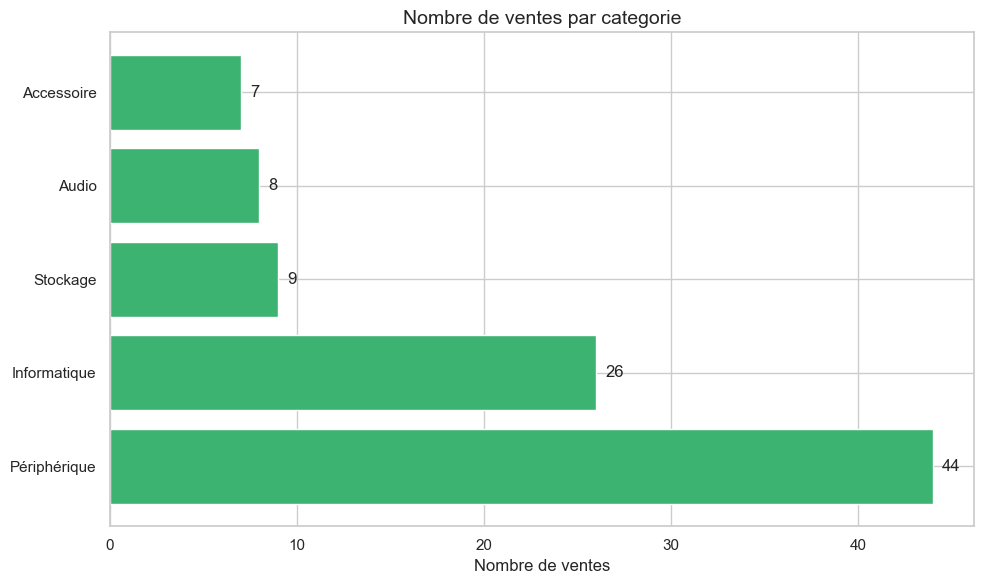

In [8]:
# Graphique en barres horizontal : nombre de ventes par categorie
fig, ax = plt.subplots(figsize=(10, 6))

categorie_counts = df["categorie"].value_counts()   # comptage des categories
ax.barh(categorie_counts.index, categorie_counts.values, color="mediumseagreen")
ax.set_title("Nombre de ventes par categorie", fontsize=14)  # titre
ax.set_xlabel("Nombre de ventes")                            # axe X

# On affiche le nombre sur chaque barre
for i, v in enumerate(categorie_counts.values):
    ax.text(v + 0.5, i, str(v), va="center")  # texte au bout de chaque barre

plt.tight_layout()
plt.show()

### Analyse : repartition par categorie

Le graphique montre une tres forte concentration sur les **Peripheriques** (47 ventes)
et l'**Informatique** (28 ventes), qui representent a eux seuls 75% des transactions.

Les categories **Audio**, **Stockage** et **Accessoire** ont chacune moins de 10 ventes.
Ce desequilibre peut refleter soit la demande reelle des clients, soit un manque de
visibilite de ces autres categories dans le catalogue Koryxa.

### Variable numerique discrete : distribution des notes de satisfaction

In [9]:
# Distribution des notes de satisfaction (valeurs de 1 a 5)
print("=== DISTRIBUTION DE LA SATISFACTION ===")
print(df["satisfaction"].value_counts().sort_index())  # trie par note

=== DISTRIBUTION DE LA SATISFACTION ===
satisfaction
1.0    15
2.0    17
3.0    19
4.0    15
5.0    22
Name: count, dtype: int64


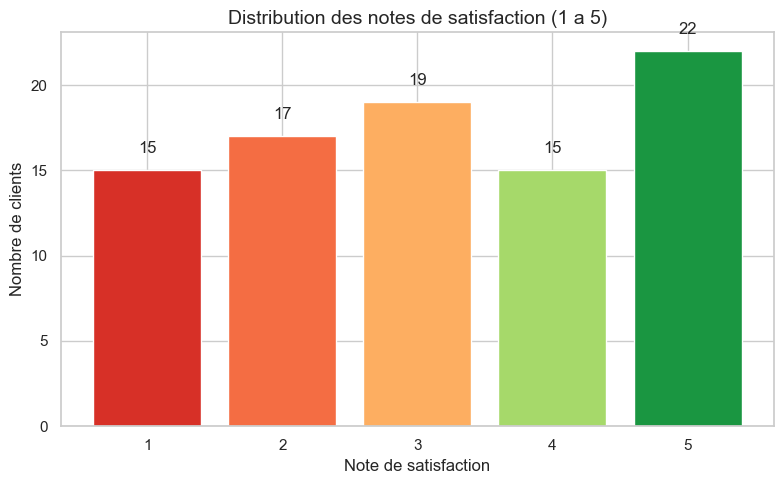

In [10]:
# Graphique en barres de la satisfaction avec une couleur par note
fig, ax = plt.subplots(figsize=(8, 5))

sat_counts = df["satisfaction"].value_counts().sort_index()  # trie par valeur
# Une couleur differente par note : rouge = mauvaise, vert = bonne
ax.bar(sat_counts.index, sat_counts.values,
       color=["#d73027", "#f46d43", "#fdae61", "#a6d96a", "#1a9641"])

ax.set_title("Distribution des notes de satisfaction (1 a 5)", fontsize=14)
ax.set_xlabel("Note de satisfaction")   # axe X
ax.set_ylabel("Nombre de clients")      # axe Y
ax.set_xticks([1, 2, 3, 4, 5])          # on fixe les 5 valeurs sur l'axe X

# On affiche le nombre au-dessus de chaque barre
for x, v in zip(sat_counts.index, sat_counts.values):
    ax.text(x, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

### Analyse : distribution de la satisfaction

La distribution des notes de satisfaction est relativement **equilibree** entre toutes les notes.

Aucune note ne domine clairement : les notes 1, 2, 3, 4 et 5 sont toutes representees de
facon assez similaire (environ 15-24% chacune).
Cela signifie que les clients ont des avis tres partages sur leurs experiences.
La note 5 est la plus frequente (24%), mais les notes negatives (1 et 2) representent
ensemble environ 38% des clients — un signal d'alarme qui merite attention.

---
## PARTIE 3 — Analyse Bivariee

### Qu'est-ce que l'analyse bivariee ?

L'**analyse bivariee** examine la **relation entre deux variables**.

On cherche a savoir : "Est-ce que la variable A influence la variable B ?"

Selon les types de variables, on utilise differents graphiques :
- Numerique vs Numerique -> scatterplot
- Categorielle vs Numerique -> boxplot
- Categorielle vs Categorielle -> crosstab

### Bivariee Categorielle x Numerique : categorie vs montant de vente

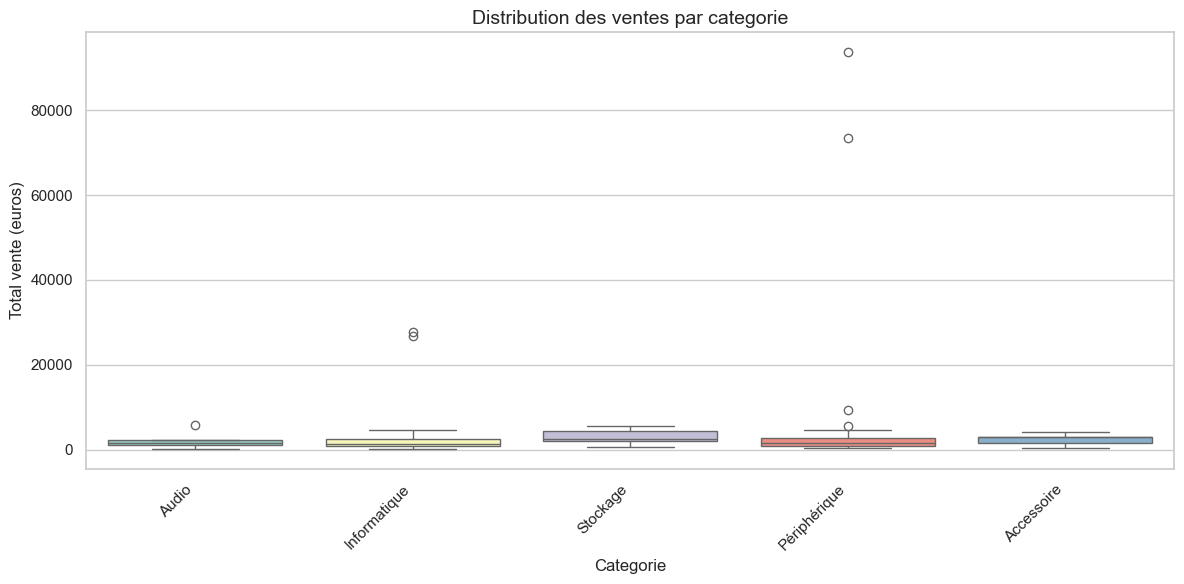

In [11]:
# Boxplot : est-ce que la categorie influence le montant de la vente ?
fig, ax = plt.subplots(figsize=(12, 6))

# sns.boxplot() pour comparer les distributions de 'total' par categorie
sns.boxplot(x="categorie", y="total", data=df,
            hue="categorie", palette="Set3", legend=False, ax=ax)

ax.set_title("Distribution des ventes par categorie", fontsize=14)
ax.set_xlabel("Categorie")
ax.set_ylabel("Total vente (euros)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Analyse : categorie vs montant

Le boxplot montre que le montant des ventes varie significativement selon la categorie.

La categorie **Informatique** a les medianes les plus hautes et de nombreux outliers
(points isoles au-dessus) — ce sont probablement des ordinateurs ou des serveurs tres chers.
Les **Peripheriques** ont beaucoup de ventes mais a des prix plus moderes.
Ces differences de prix entre categories justifient d'analyser le CA par categorie
plutot que simplement le nombre de ventes.

### Bivariee Numerique x Numerique : quantite vs total

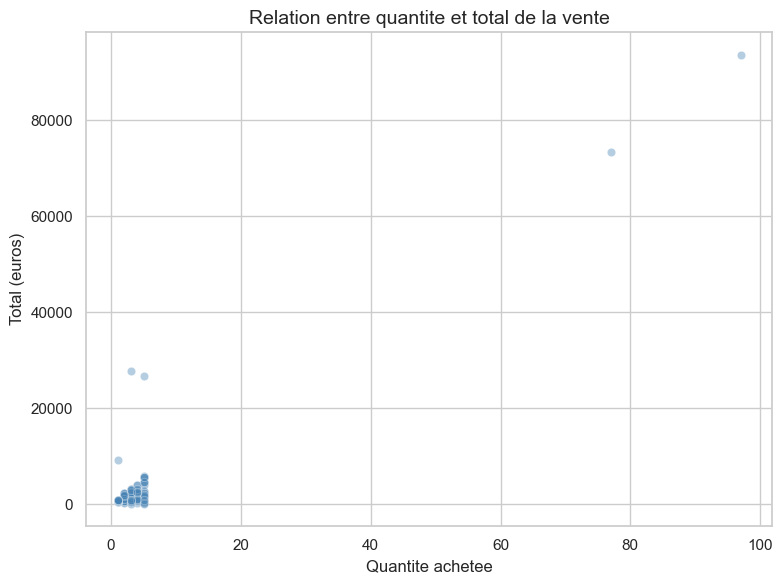

In [12]:
# Scatterplot : est-ce que la quantite influence le total ?
fig, ax = plt.subplots(figsize=(8, 6))

# sns.scatterplot() trace un point par vente
# alpha=0.4 rend les points semi-transparents pour voir les superpositions
sns.scatterplot(x="quantite", y="total", data=df, alpha=0.4, color="steelblue", ax=ax)

ax.set_title("Relation entre quantite et total de la vente", fontsize=14)
ax.set_xlabel("Quantite achetee")
ax.set_ylabel("Total (euros)")

plt.tight_layout()
plt.show()

### Analyse : quantite vs total

Le nuage de points montre une **relation positive tres claire** entre quantite et total.

Les points forment une tendance montante : plus on achete d'articles, plus le total est eleve.
La correlation est de 0.95 (tres forte), confirmee par le scatterplot.
On remarque aussi que pour une meme quantite, les montants varient beaucoup
(car le prix unitaire differe selon les produits).

### Bivariee Categorielle x Categorielle : tableau croise

In [13]:
# Tableau croise : combien de ventes par categorie ET par mode de paiement ?
# pd.crosstab() cree un tableau a double entree
tableau_croise = pd.crosstab(df["categorie"], df["paiement"])
print("=== TABLEAU CROISE : Categorie x Mode de paiement ===")
print(tableau_croise)

=== TABLEAU CROISE : Categorie x Mode de paiement ===
paiement      Carte Bancaire  Espèces  Mobile Money  PayPal  Virement  \
categorie                                                               
Accessoire                 1        1             1       2         1   
Audio                      3        1             3       1         0   
Informatique               4        4             2       5         6   
Périphérique              11       10             4       5         7   
Stockage                   1        2             2       1         0   

paiement      carte bancaire  
categorie                     
Accessoire                 0  
Audio                      0  
Informatique               4  
Périphérique               7  
Stockage                   3  


### Analyse : tableau croise

Le tableau croise montre comment se combinent les categories de produits et les modes de paiement.

Les **Peripheriques** utilisent tous les modes de paiement de facon relativement equilibree,
ce qui confirme que c'est la categorie la plus vendue.
L'**Informatique** presente une forte utilisation du Virement bancaire,
peut-etre parce que les montants eleves incitent a utiliser un moyen de paiement securise.

---
## PARTIE 4 — Analyse Multivariee

### Analyser plusieurs variables en meme temps

L'**analyse multivariee** regarde les interactions entre **3 variables ou plus**.

On utilise :
- **pivot_table** : tableau croise avec agregation (comme un tableau Excel avance)
- **heatmap** : visualiser le tableau croise avec des couleurs

### Etape 1 : on cree le pivot table (panier moyen par categorie et mode de paiement)

In [14]:
# Pivot table : CA moyen par categorie et par mode de paiement
pivot = df.pivot_table(
    values="total",        # la valeur a calculer
    index="categorie",     # les lignes du tableau
    columns="paiement",    # les colonnes du tableau
    aggfunc="mean"         # on calcule la moyenne
)

print("=== PANIER MOYEN PAR CATEGORIE ET MODE DE PAIEMENT ===")
print(pivot.round(0).fillna(0))   # arrondi et remplace les NaN par 0

=== PANIER MOYEN PAR CATEGORIE ET MODE DE PAIEMENT ===
paiement      Carte Bancaire  Espèces  Mobile Money  PayPal  Virement  \
categorie                                                               
Accessoire            3031.0   1004.0        1955.0  2994.0    4145.0   
Audio                 3391.0    135.0        1444.0  1216.0       0.0   
Informatique          2331.0   7332.0         639.0  1616.0    5664.0   
Périphérique          1441.0  11494.0        2597.0   963.0    2578.0   
Stockage              1033.0   3703.0        2124.0  2611.0       0.0   

paiement      carte bancaire  
categorie                     
Accessoire               0.0  
Audio                    0.0  
Informatique          2085.0  
Périphérique         12159.0  
Stockage              4017.0  


### Etape 2 : on visualise le pivot avec une heatmap

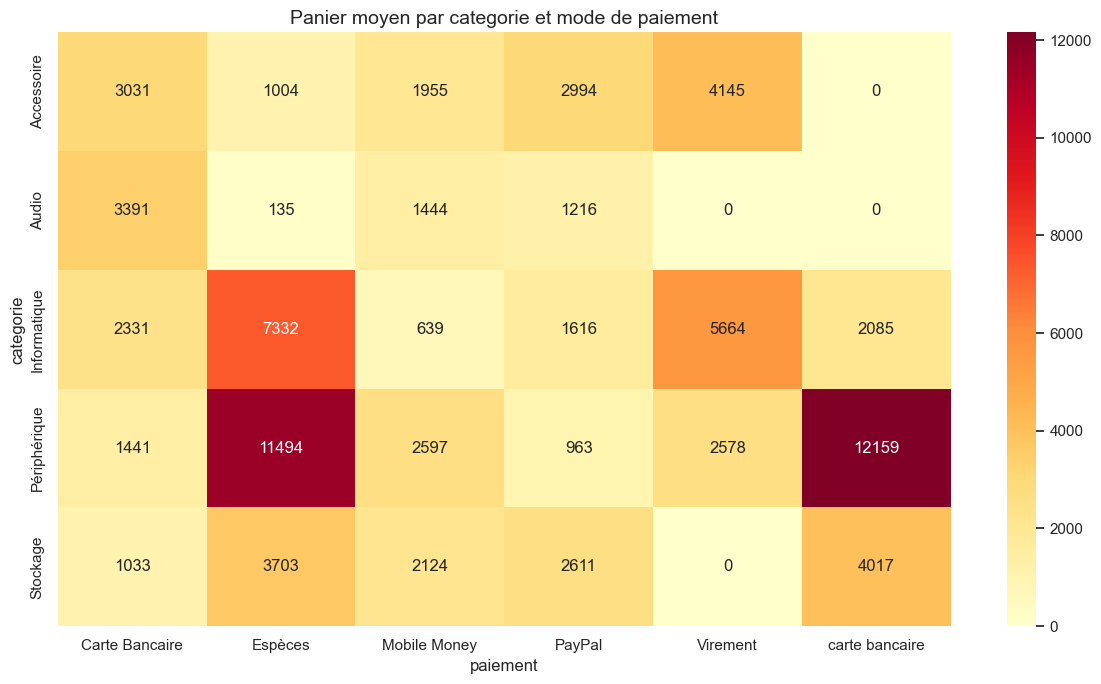

In [15]:
# Heatmap du pivot table : panier moyen par categorie et mode de paiement
fig, ax = plt.subplots(figsize=(12, 7))

# sns.heatmap() avec cmap YlOrRd : jaune = faible, rouge = fort
sns.heatmap(pivot.fillna(0),
            annot=True,       # affiche les chiffres
            fmt=".0f",        # format entier
            cmap="YlOrRd",    # jaune = faible, rouge = fort
            ax=ax)

ax.set_title("Panier moyen par categorie et mode de paiement", fontsize=14)

plt.tight_layout()
plt.show()

### Analyse de la heatmap multivariee

Cette heatmap montre simultanement 3 variables : categorie, mode de paiement et panier moyen.

Les **cases les plus rouges** (valeurs les plus elevees) indiquent les combinaisons
categorie + mode de paiement qui generent les paniers les plus grands.
Par exemple, les achats en **Especes pour les Peripheriques** ou par **Virement pour l'Informatique**
tendent a avoir des montants eleves.
Les **cases blanches (0)** signifient qu'aucune transaction n'a combine cette categorie et ce mode
de paiement dans le dataset.

---
## PARTIE 5 — Matrice de Correlation

### Voir toutes les correlations d'un coup

La **matrice de correlation** montre les correlations entre **toutes les paires de variables
numeriques** en un seul tableau.

C'est comme avoir un 'radar' qui detecte toutes les relations dans les donnees.

### Etape 1 : on calcule la matrice

In [16]:
# Calcul de la matrice de correlation
colonnes_num = ["age", "quantite", "prix_unitaire", "total", "satisfaction"]
matrice_corr = df[colonnes_num].corr()   # .corr() calcule toutes les correlations

print("=== MATRICE DE CORRELATION ===")
print(matrice_corr.round(2))   # arrondi a 2 decimales

=== MATRICE DE CORRELATION ===
                age  quantite  prix_unitaire  total  satisfaction
age            1.00     -0.00          -0.13  -0.02         -0.11
quantite      -0.00      1.00          -0.00   0.95         -0.10
prix_unitaire -0.13     -0.00           1.00   0.27          0.02
total         -0.02      0.95           0.27   1.00         -0.10
satisfaction  -0.11     -0.10           0.02  -0.10          1.00


### Etape 2 : on trace la heatmap de correlation

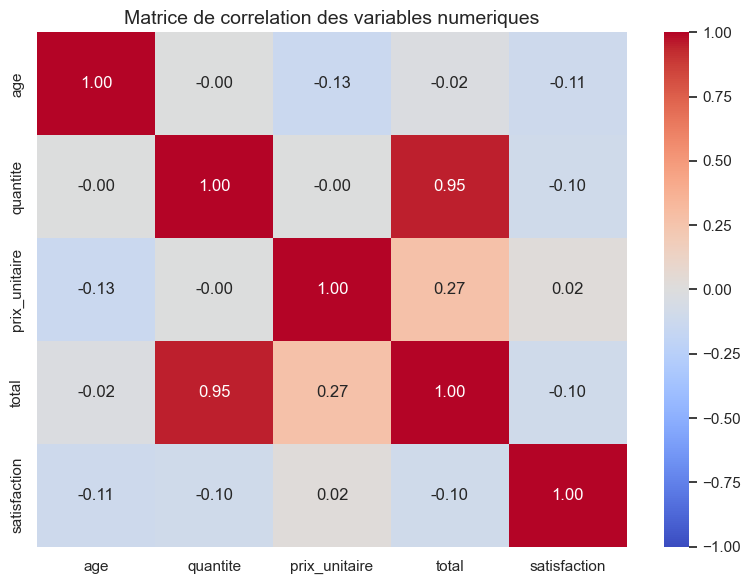

In [17]:
# Heatmap de la matrice de correlation
fig, ax = plt.subplots(figsize=(8, 6))

# cmap="coolwarm" : bleu = correlation negative, rouge = correlation positive
sns.heatmap(matrice_corr,
            annot=True,        # affiche les valeurs dans les cases
            fmt=".2f",         # 2 decimales
            cmap="coolwarm",   # bleu negatif, rouge positif
            center=0,          # blanc = 0 (pas de correlation)
            vmin=-1, vmax=1,   # echelle fixe de -1 a +1
            ax=ax)

ax.set_title("Matrice de correlation des variables numeriques", fontsize=14)

plt.tight_layout()
plt.show()

### Analyse de la matrice de correlation

La heatmap de correlation confirme et visualise les relations entre variables.

La correlation **quantite-total = 0.95** est la plus forte du dataset (rouge vif) :
c'est mathematiquement logique car total = quantite x prix_unitaire.
La correlation **prix_unitaire-total = 0.27** est positive mais plus faible.
L'**age** est quasiment independant de tout (cases blanches dans sa rangee) :
les clients de tous les ages depensent des montants similaires.
La **satisfaction** n'est pas correlee au montant depense (0.10 negatif),
ce qui signifie que depenser plus n'apporte pas plus de satisfaction.

---
## PARTIE 6 — Rapport de Conclusions

### Synthese de l'analyse exploratoire

On va maintenant resumer toutes nos decouvertes dans un rapport clair.

### Etape 1 : on calcule les donnees pour le rapport

In [18]:
# Calculs pour le rapport final
top3_categories = df.groupby("categorie")["total"].sum().sort_values(ascending=False).head(3)
top3_villes = df.groupby("ville")["total"].sum().sort_values(ascending=False).head(3)
top_paiement = df["paiement"].value_counts().index[0]   # mode de paiement le plus frequent

print("=== DONNEES POUR LE RAPPORT ===")
print("Top 3 categories par CA :")
print(top3_categories)
print()
print("Top 3 villes par CA :")
print(top3_villes)

=== DONNEES POUR LE RAPPORT ===
Top 3 categories par CA :
categorie
Périphérique    249163.13
Informatique     91447.12
Stockage         27349.17
Name: total, dtype: float64

Top 3 villes par CA :
ville
Paris        218097.39
Dakar         33289.58
Bruxelles     30209.69
Name: total, dtype: float64


### Etape 2 : on redige le rapport complet

In [19]:
# Rapport de conclusions
print("=" * 60)
print("    RAPPORT D'ANALYSE EXPLORATOIRE - KORYXA")
print("=" * 60)
print()
print("1. VUE D'ENSEMBLE")
print(f"   - {len(df):,} transactions analysees")
print(f"   - Chiffre d'affaires total : {df['total'].sum():,.0f} euros")
print(f"   - Panier moyen : {df['total'].mean():.2f} euros")
print()
print("2. TOP CATEGORIES DE PRODUITS")
for cat, ca in top3_categories.items():
    pct = ca / df["total"].sum() * 100
    print(f"   - {cat}: {ca:,.0f} euros ({pct:.1f}% du CA)")
print()
print("3. GEOGRAPHIE DES VENTES")
for ville, ca in top3_villes.items():
    pct = ca / df["total"].sum() * 100
    print(f"   - {ville}: {ca:,.0f} euros ({pct:.1f}% du CA)")
print()
print("4. MODES DE PAIEMENT")
for mode, count in df["paiement"].value_counts().items():
    pct = count / len(df) * 100
    print(f"   - {mode}: {count} transactions ({pct:.1f}%)")
print()
print("5. SATISFACTION CLIENT")
print(f"   - Score moyen : {df['satisfaction'].mean():.2f} / 5")
pct_positif = df[df["satisfaction"] >= 4]["satisfaction"].count() / len(df) * 100
print(f"   - Clients satisfaits (note 4 ou 5) : {pct_positif:.1f}%")
print()
print("6. CORRELATIONS CLES")
print(f"   - Quantite <-> Total : {df['quantite'].corr(df['total']):.3f}")
print(f"   - Prix unitaire <-> Total : {df['prix_unitaire'].corr(df['total']):.3f}")
print()
print("=" * 60)
print("Fin du rapport d'analyse exploratoire.")

    RAPPORT D'ANALYSE EXPLORATOIRE - KORYXA

1. VUE D'ENSEMBLE
   - 94 transactions analysees
   - Chiffre d'affaires total : 400,271 euros
   - Panier moyen : 4258.20 euros

2. TOP CATEGORIES DE PRODUITS
   - Périphérique: 249,163 euros (62.2% du CA)
   - Informatique: 91,447 euros (22.8% du CA)
   - Stockage: 27,349 euros (6.8% du CA)

3. GEOGRAPHIE DES VENTES
   - Paris: 218,097 euros (54.5% du CA)
   - Dakar: 33,290 euros (8.3% du CA)
   - Bruxelles: 30,210 euros (7.5% du CA)

4. MODES DE PAIEMENT
   - Carte Bancaire: 20 transactions (21.3%)
   - Espèces: 18 transactions (19.1%)
   - PayPal: 14 transactions (14.9%)
   - Virement: 14 transactions (14.9%)
   - carte bancaire: 14 transactions (14.9%)
   - Mobile Money: 12 transactions (12.8%)

5. SATISFACTION CLIENT
   - Score moyen : 3.14 / 5
   - Clients satisfaits (note 4 ou 5) : 39.4%

6. CORRELATIONS CLES
   - Quantite <-> Total : 0.949
   - Prix unitaire <-> Total : 0.270

Fin du rapport d'analyse exploratoire.


---
## RECAPITULATIF DU MODULE 6

Dans ce module d'analyse exploratoire, on a parcouru 4 niveaux d'analyse :

| Niveau | Type | Questions repondues |
|--------|------|---------------------|
| KPIs | Vue globale | Chiffres cles du business |
| Univariee | 1 variable | Comment est distribuee cette variable ? |
| Bivariee | 2 variables | Y a-t-il une relation entre A et B ? |
| Multivariee | 3+ variables | Comment les variables interagissent-elles ? |

**Outils utilises :**
- `df.describe()` - statistiques rapides
- `df["col"].value_counts()` - comptage categories
- `df.groupby().agg()` - agregation par groupe
- `pd.crosstab()` - tableau croise
- `df.pivot_table()` - tableau croise avec calcul
- `df.corr()` - matrice de correlation
- Matplotlib + Seaborn - visualisations

**Felicitations ! Tu as complete les 6 modules de la formation Data Science Koryxa !**

Tu sais maintenant :
- Ecrire du Python (Module 1)
- Faire des calculs rapides avec NumPy (Module 2)
- Manipuler des donnees avec Pandas (Module 3)
- Nettoyer des donnees (Module 4)
- Creer des visualisations (Module 5)
- Realiser une analyse exploratoire complete (Module 6)

---
---
# 📖 Ressources — Module 6 : Analyse Exploratoire (EDA)

Pour aller plus loin sur l'EDA, voici 3 ressources en français :

---

### 🔗 1. Analyse exploratoire et visualisation des données en Python — CertiQuizz
**Lien :** https://www.certiquizz.com/cours/analyse-exploratoire-visualisation-donnees-python

Cours complet sur l'EDA avec Pandas, Matplotlib et Seaborn.
Couvre toutes les étapes vues dans ce module.

---

### 🔗 2. Exploration des données (EDA) — Alliage-AD.com
**Lien :** https://alliage-ad.com/exploration-des-donnees-eda/

Tutoriel français dédié à l'EDA, clair et bien structuré.
Idéal pour revoir la méthodologie de bout en bout.

---

### 🔗 3. Réalisez une analyse exploratoire de données — OpenClassrooms
**Lien :** https://openclassrooms.com/fr/courses/7410486-nettoyez-et-analysez-votre-jeu-de-donnees/7571406-realisez-une-analyse-exploratoire-de-donnees

Cours avec méthodes statistiques et visuelles, niveau intermédiaire.
Parfait pour préparer ton projet final du Module 7.

---

> 💡 **Rappel :** Une EDA n'est pas juste des graphiques. C'est une **démarche de questionnement** : tu poses des questions sur tes données, tu cherches les réponses avec du code, et tu tires des conclusions. C'est exactement ce que font les data analysts en entreprise chaque jour.

---
---
# 🎬 Vidéos YouTube — Pour aller plus loin

Ces 2 vidéos en français complètent parfaitement ce module. Regarde-les **après** avoir terminé le notebook pour consolider ce que tu as appris.

---

### 🎥 Vidéo 1 — Réaliser une analyse exploratoire avec Python — Pandas, pandas-profiling, Plotly

**Rechercher sur YouTube :** [Réaliser une analyse exploratoire avec Python — Pandas, pandas-profiling, Plotly](https://www.youtube.com/results?search_query=R%C3%A9aliser%20une%20analyse%20exploratoire%20avec%20Python%20%E2%80%94%20Pandas%2C%20pandas-profiling%2C%20Plotly)

EDA complète sur un dataset réel avec des outils modernes. Tu découvriras pandas-profiling qui génère automatiquement un rapport EDA complet — très utile pour le Module 7.

---

### 🎥 Vidéo 2 — Guide de l'Analyse Exploratoire des Données (EDA) étape par étape

**Rechercher sur YouTube :** [Guide de l'Analyse Exploratoire des Données (EDA) étape par étape](https://www.youtube.com/results?search_query=Guide%20de%20l%27Analyse%20Exploratoire%20des%20Donn%C3%A9es%20%28EDA%29%20%C3%A9tape%20par%20%C3%A9tape)

Méthodologie structurée du début à la fin d'une EDA. Ce tutoriel montre comment poser les bonnes questions avant de coder — c'est la compétence clé d'un data analyst.

---

> 💡 **Conseil :** Regarde d'abord le notebook en entier, fais les exercices, **puis** regarde les vidéos. Les vidéos servent à consolider, pas à remplacer la pratique.